# CatBoost — Attribute Effects via SHAP

This notebook measures the impact of each attribute on the outcome of the incident (`severity`) using **SHAP Global E[φ_k]** as the effect metric.

SHAP is computed on the **probability scale**, which ensures that its values are directly comparable to the **Average Marginal Effects (AMEs) from logistic regression**: both express the average change in P(severity = 1) attributed to each variable.

> **CatBoost specificity:** CatBoost provides a native SHAP implementation via `get_feature_importance(type='ShapValues')`, which returns a 3D tensor `(n_obs, n_features + 1)` including the bias term in the last column. The approach adopted here uses SHAP’s `TreeExplainer` with `model_output="probability"`, maintaining methodological consistency with the other models. Categorical variables are passed directly to CatBoost without prior encoding.

In [22]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [23]:
url_train = "../../database/completo/final/df_train.csv"
url_test = "../../database/completo/final/df_test.csv"

# carrega dados
df_train = pd.read_csv(url_train, sep=",", encoding="UTF-8")
df_test = pd.read_csv(url_test, sep=",", encoding="UTF-8")

In [24]:
X_train = df_train.drop(columns=["grave", "ano"])
y_train = df_train["grave"]

X_test = df_test.drop(columns=["grave", "ano"])
y_test = df_test["grave"]

In [25]:
# ============================================================
# IDENTIFICACAO DAS COLUNAS CATEGORICAS
# ============================================================
# O CatBoost aceita categoricas diretamente (sem encoding),
# desde que sejam informadas via cat_features.
# Colunas object sao identificadas automaticamente.

cat_features = [col for col in X_train.columns if X_train[col].dtype == object]
cat_indices  = [X_train.columns.get_loc(c) for c in cat_features]

# CatBoost exige que categoricas sejam string, nao NaN
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("missing")
    X_test[col]  = X_test[col].astype(str).fillna("missing")

print(f"Colunas categoricas ({len(cat_features)}): {cat_features}")
print(f"Indices: {cat_indices}")

Colunas categoricas (0): []
Indices: []


In [26]:
from catboost import CatBoostClassifier

# Desbalanceamento via scale_pos_weight:
# equivalente ao class_weight='balanced' dos demais modelos.
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Desbalanceamento -- negativos: {n_neg:,} | positivos: {n_pos:,}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

cat = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="AUC",
    cat_features=cat_indices,
    random_seed=42,
    verbose=0          # suprime log de treinamento
)

cat.fit(X_train, y_train)
print("\nModelo treinado.")

Desbalanceamento -- negativos: 486,401 | positivos: 72,446
scale_pos_weight = 6.71

Modelo treinado.


In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]

print("\n=== Metricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Metricas (Teste 2025) ===
Accuracy : 0.6375
Precision: 0.1852
Recall   : 0.4616
F1-score : 0.2644
AUC      : 0.5756

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.67      0.76     62109
           1       0.19      0.46      0.26     10201

    accuracy                           0.64     72310
   macro avg       0.53      0.56      0.51     72310
weighted avg       0.78      0.64      0.69     72310



In [28]:
# ============================================================
# SHAP na escala de PROBABILIDADE -- TreeExplainer
# ============================================================
# O CatBoost tem suporte nativo no TreeExplainer do SHAP.
# model_output="probability" garante que cada phi_k(i) esteja
# na escala de P(gravidade=1), comparavel aos AMEs.
#
# ATENCAO: o background deve usar os mesmos dados de treino
# (com as colunas categoricas ja convertidas para string),
# pois o CatBoost processa categoricas internamente.

X_background  = shap.sample(X_train, 500, random_state=42)
X_test_sample = X_test.sample(min(5000, len(X_test)), random_state=42)
n_obs      = len(X_test_sample)
n_features = X_test_sample.shape[1]

explainer = shap.TreeExplainer(
    cat,
    data=X_background,
    model_output="probability",
    feature_perturbation="interventional"
)

print("Calculando SHAP values...")
shap_values = explainer.shap_values(X_test_sample)
raw = np.array(shap_values)

print(f"Formato bruto retornado pelo TreeExplainer: {raw.shape}")

# Normaliza para (n_amostras, n_features) -- classe 1
if isinstance(shap_values, list):
    shap_array = np.array(shap_values[1])
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[0] == 2:
    shap_array = raw[1]
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[2] == 2:
    shap_array = raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_array = raw
    expected_value = (
        explainer.expected_value[1]
        if hasattr(explainer.expected_value, '__len__')
        else explainer.expected_value
    )

# Corrige transposicao se necessario
if shap_array.shape == (n_features, n_obs):
    print("[AVISO] array transposto detectado -- corrigindo orientacao.")
    shap_array = shap_array.T

print(f"Formato dos SHAP values (classe 1): {shap_array.shape}")
print(f"Valor esperado (phi_0):             {expected_value:.6f}")

Calculando SHAP values...


 99%|===================| 4959/5000 [01:02<00:00]        

Formato bruto retornado pelo TreeExplainer: (5000, 20)
Formato dos SHAP values (classe 1): (5000, 20)
Valor esperado (phi_0):             0.375300


In [29]:
# ============================================================
# VALIDACAO da escala de probabilidade
# ============================================================
# Propriedade de eficiencia:
#   phi_0 + sum_k(phi_k(i)) = P_hat(i) = P(gravidade=1 | X=x_i)

shap_reconstructed = expected_value + shap_array.sum(axis=1)
prob_real = cat.predict_proba(X_test_sample)[:, 1]

max_desvio  = np.abs(shap_reconstructed - prob_real).max()
mean_desvio = np.abs(shap_reconstructed - prob_real).mean()

print(f"phi_0 (valor esperado):                         {expected_value:.6f}")
print(f"Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   {max_desvio:.2e}")
print(f"Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   {mean_desvio:.2e}")

if max_desvio < 1e-3:
    print("\n[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.")
else:
    print("\n[ATENCAO] Desvio alto. Tente o KernelExplainer como fallback:")
    print("  def predict_proba_cat(X): return cat.predict_proba(X)[:, 1]")
    print("  explainer = shap.KernelExplainer(predict_proba_cat, X_background)")
    print("  shap_values = explainer.shap_values(X_test_sample, silent=True)")

phi_0 (valor esperado):                         0.375300
Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   6.25e-09
Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   9.85e-10

[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.


In [30]:
# ============================================================
# SHAP GLOBAL -- E[phi_k]
# ============================================================
# Medida de efeito do CatBoost, na mesma escala e com a
# mesma interpretacao dos AMEs da regressao logistica:
#   "variacao media em P(gravidade=1) atribuida a variavel k"

# E[phi_k]: efeito medio com sinal -- use para comparar entre modelos
shap_global_mean = pd.Series(
    shap_array.mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_global_E[phi_k]"
)

# E[|phi_k|]: importancia absoluta -- use apenas para ranqueamento
# (perde o sinal do efeito; nao usar para comparacao com AME)
shap_global_abs = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_importancia_E[|phi_k|]"
)

resultado = pd.concat([shap_global_mean, shap_global_abs], axis=1)
resultado = resultado.sort_values(by="SHAP_importancia_E[|phi_k|]", ascending=False)

print("\n=== Impacto dos atributos na probabilidade do desfecho (CatBoost) ===")
print("SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade")
print("SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento")
print()
print(resultado.to_string())


=== Impacto dos atributos na probabilidade do desfecho (CatBoost) ===
SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade
SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento

                    SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
uf_br_km                        0.038960                     0.159667
vel_max                         0.005891                     0.041832
frequencia                      0.004300                     0.018829
turno_sin                      -0.003698                     0.017795
uso_solo                       -0.000289                     0.015890
tipo_pista                     -0.003132                     0.014403
distancia_radar_m              -0.000097                     0.009178
turno_cos                      -0.001672                     0.008982
pista_molhada                   0.002467                     0.007410
dia_semana_sin                 -0.000303                     0.005677
dec

In [31]:
# ============================================================
# INTERPRETACAO DOS EFEITOS
# ============================================================
print("\n=== Interpretacao dos efeitos ===")
print("Variacao media em P(gravidade=1) atribuida a cada variavel.\n")

for var, row in resultado.iterrows():
    impacto     = row["SHAP_global_E[phi_k]"]
    importancia = row["SHAP_importancia_E[|phi_k|]"]

    if importancia < 1e-8:
        print(f"{var:35s}: SEM EFEITO")
    elif impacto > 0:
        print(f"{var:35s}: AUMENTA a probabilidade em +{impacto:.4f} (em media)")
    else:
        print(f"{var:35s}: REDUZ  a probabilidade em {impacto:.4f} (em media)")


=== Interpretacao dos efeitos ===
Variacao media em P(gravidade=1) atribuida a cada variavel.

uf_br_km                           : AUMENTA a probabilidade em +0.0390 (em media)
vel_max                            : AUMENTA a probabilidade em +0.0059 (em media)
frequencia                         : AUMENTA a probabilidade em +0.0043 (em media)
turno_sin                          : REDUZ  a probabilidade em -0.0037 (em media)
uso_solo                           : REDUZ  a probabilidade em -0.0003 (em media)
tipo_pista                         : REDUZ  a probabilidade em -0.0031 (em media)
distancia_radar_m                  : REDUZ  a probabilidade em -0.0001 (em media)
turno_cos                          : REDUZ  a probabilidade em -0.0017 (em media)
pista_molhada                      : AUMENTA a probabilidade em +0.0025 (em media)
dia_semana_sin                     : REDUZ  a probabilidade em -0.0003 (em media)
declive                            : AUMENTA a probabilidade em +0.0003 (em medi

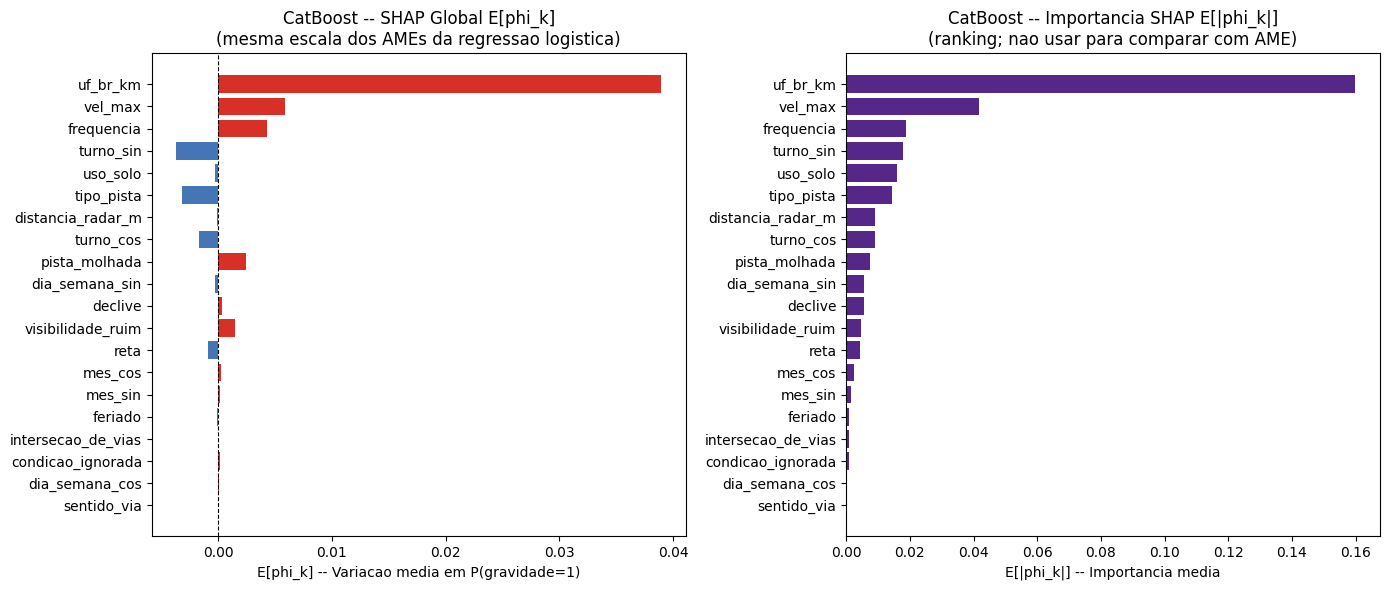

Grafico salvo em catboost_shap_efeitos.png


In [32]:
# ============================================================
# VISUALIZACOES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: efeito medio com sinal (mesma leitura que AME)
cores = ['#d73027' if v > 0 else '#4575b4' for v in resultado["SHAP_global_E[phi_k]"]]
axes[0].barh(resultado.index, resultado["SHAP_global_E[phi_k]"], color=cores)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("E[phi_k] -- Variacao media em P(gravidade=1)")
axes[0].set_title("CatBoost -- SHAP Global E[phi_k]\n(mesma escala dos AMEs da regressao logistica)")
axes[0].invert_yaxis()

# Grafico 2: importancia absoluta (ranking)
axes[1].barh(resultado.index, resultado["SHAP_importancia_E[|phi_k|]"], color='#542788')
axes[1].set_xlabel("E[|phi_k|] -- Importancia media")
axes[1].set_title("CatBoost -- Importancia SHAP E[|phi_k|]\n(ranking; nao usar para comparar com AME)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("catboost_shap_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em catboost_shap_efeitos.png")

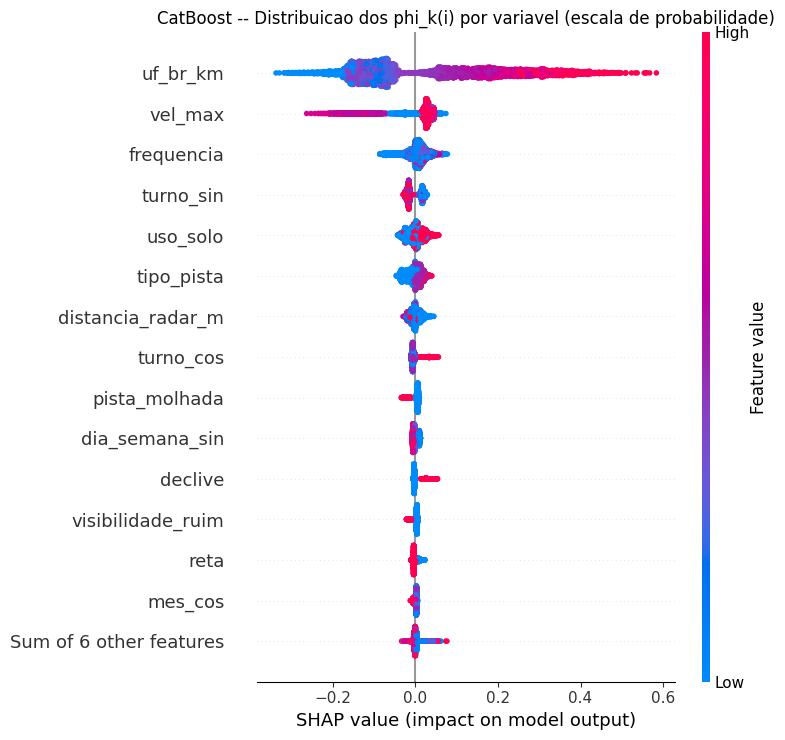

Beeswarm salvo em catboost_shap_beeswarm.png


In [33]:
# ============================================================
# BEESWARM PLOT -- distribuicao local dos phi_k(i)
# ============================================================
# Revela heterogeneidade dos efeitos alem da media global.
# O eixo X esta em unidades de probabilidade.

shap_explanation = shap.Explanation(
    values=shap_array,
    base_values=expected_value,
    data=X_test_sample.values,
    feature_names=list(X_test_sample.columns)
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("CatBoost -- Distribuicao dos phi_k(i) por variavel (escala de probabilidade)")
plt.tight_layout()
plt.savefig("catboost_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm salvo em catboost_shap_beeswarm.png")

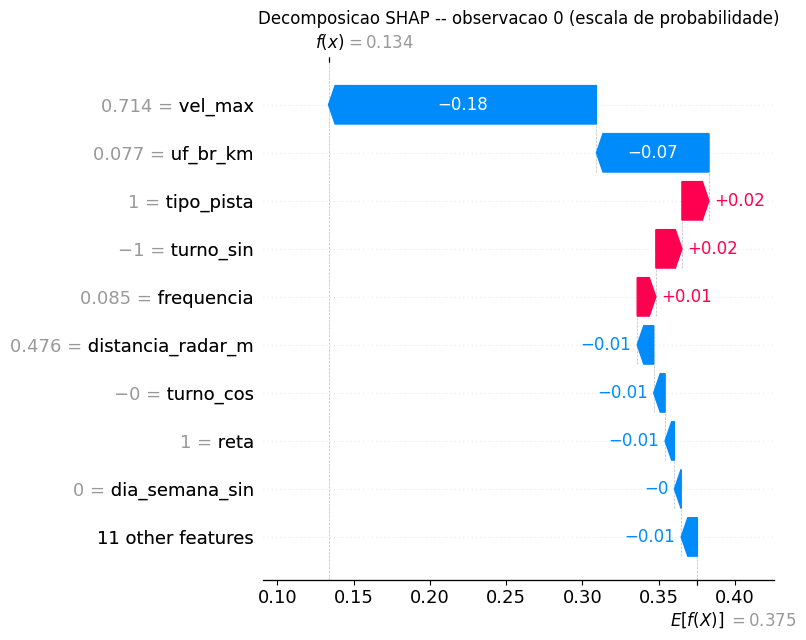

Waterfall salvo em catboost_shap_waterfall.png


In [34]:
# ============================================================
# WATERFALL PLOT -- decomposicao de uma observacao individual
# ============================================================
# Mostra phi_0 + sum(phi_k(i)) = P_hat(i) para uma observacao.
# Util para auditar a escala e verificar a propriedade de eficiencia.

idx = 0  # altere para inspecionar outra observacao

plt.figure()
shap.plots.waterfall(shap_explanation[idx], show=False)
plt.title(f"Decomposicao SHAP -- observacao {idx} (escala de probabilidade)")
plt.tight_layout()
plt.savefig("catboost_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall salvo em catboost_shap_waterfall.png")

In [35]:
def shap_cyclic_analysis(shap_values, X, sin_name, cos_name):
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    phi_sin = shap_values[:, idx_sin]
    phi_cos = shap_values[:, idx_cos]
    
    # 🔹 1. Importância (análogo ao SHAP |φ|)
    importance = np.mean(np.sqrt(phi_sin**2 + phi_cos**2))
    
    # 🔹 2. Direção média (vetor médio)
    mean_sin = np.mean(phi_sin)
    mean_cos = np.mean(phi_cos)
    
    direction_amplitude = np.sqrt(mean_sin**2 + mean_cos**2)
    
    # 🔹 3. Variabilidade (quanto o efeito oscila)
    variability = np.std(phi_sin + phi_cos)
    
    return {
        "importance_cyclic": importance,
        "direction_amplitude": direction_amplitude,
        "mean_sin": mean_sin,
        "mean_cos": mean_cos,
        "variability": variability
    }

In [36]:
print(shap_cyclic_analysis(shap_values, X_train, "turno_sin", "turno_cos"))
print(shap_cyclic_analysis(shap_values, X_train, "dia_semana_sin", "dia_semana_cos"))
print(shap_cyclic_analysis(shap_values, X_train, "mes_sin", "mes_cos"))

{'importance_cyclic': np.float64(0.021027778005462787), 'direction_amplitude': np.float64(0.004057913128090229), 'mean_sin': np.float64(-0.0036976261721713057), 'mean_cos': np.float64(-0.001671591949609955), 'variability': np.float64(0.025933474004392852)}
{'importance_cyclic': np.float64(0.005713834165819407), 'direction_amplitude': np.float64(0.00030930319494465463), 'mean_sin': np.float64(-0.0003032504708555433), 'mean_cos': np.float64(6.089021537868242e-05), 'variability': np.float64(0.006414471230820438)}
{'importance_cyclic': np.float64(0.0031894447610071154), 'direction_amplitude': np.float64(0.00033637559893363), 'mean_sin': np.float64(0.00020189489198317383), 'mean_cos': np.float64(0.0002690483156406315), 'variability': np.float64(0.003733073431426172)}


In [37]:
import matplotlib.pyplot as plt

def plot_shap_cycle(shap_values, X, sin_name, cos_name, period, offset=0):
    
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    
    phi_sin = shap_values[:, idx_sin]
    phi_cos = shap_values[:, idx_cos]
    
    v = np.arange(0, period)
    theta = 2 * np.pi * (v - offset) / period
    
    # projeção média
    effect = []
    for t in theta:
        proj = phi_sin * np.sin(t) + phi_cos * np.cos(t)
        effect.append(np.mean(proj))
    
    plt.plot(v, effect, marker='o')
    plt.title(f"Ciclo SHAP: {sin_name[:-4]}")
    plt.xlabel("Posição no ciclo")
    plt.ylabel("Efeito médio (SHAP)")
    plt.grid()
    plt.show()

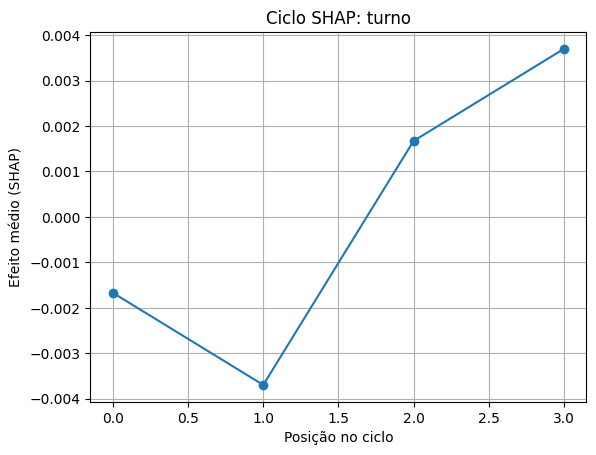

In [38]:
plot_shap_cycle(
    shap_values,
    X_train,
    "turno_sin",
    "turno_cos",
    period=4
)

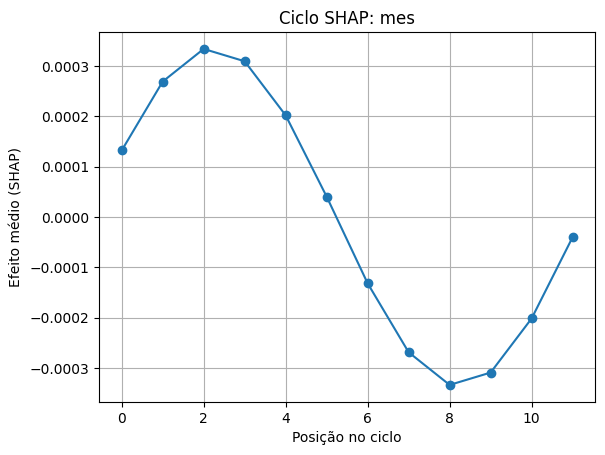

In [39]:
plot_shap_cycle(
    shap_values,
    X_train,
    "mes_sin",
    "mes_cos",
    period=12,
    offset=1
)

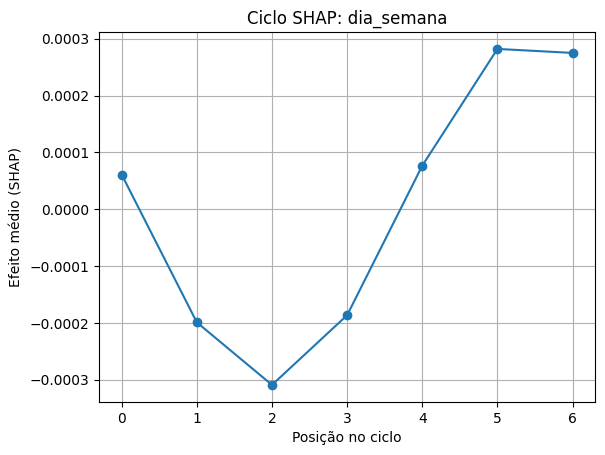

In [40]:
plot_shap_cycle(
    shap_values,
    X_train,
    "dia_semana_sin",
    "dia_semana_cos",
    period=7,
)